# Phase 2B — Probability & Distributions

**Theory covered:** Normal, Binomial, Poisson, Uniform distributions; PMF, PDF, CDF concepts.

**Tools used:** `numpy.random`, `scipy.stats`, `matplotlib`

---

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")

---
## 1. Normal (Gaussian) Distribution

The most important distribution in statistics. Describes:
- Heights, weights, measurement errors
- Model residuals (assumption of linear regression)
- Sum of many independent random variables (Central Limit Theorem)

Parameters: **μ** (mean) and **σ** (standard deviation)

In [2]:
# --- scipy.stats.norm: the normal distribution object ---
mu, sigma = 170, 10  # e.g., human heights in cm

dist = stats.norm(loc=mu, scale=sigma)

# PDF: probability density at a specific value
print(f"PDF at 170cm : {dist.pdf(170):.4f}")
print(f"PDF at 190cm : {dist.pdf(190):.4f}")

# CDF: probability that X <= value
print(f"\nP(height <= 170): {dist.cdf(170):.4f}")  # 0.5 (exactly at mean)
print(f"P(height <= 180): {dist.cdf(180):.4f}")  # ~84%
print(f"P(height <= 160): {dist.cdf(160):.4f}")  # ~16%

# P(160 < height < 180) = between -1σ and +1σ
p_within_1sigma = dist.cdf(180) - dist.cdf(160)
print(f"\nP(160 < height < 180) = {p_within_1sigma:.4f}")  # ~68.3%

PDF at 170cm : 0.0399
PDF at 190cm : 0.0054

P(height <= 170): 0.5000
P(height <= 180): 0.8413
P(height <= 160): 0.1587

P(160 < height < 180) = 0.6827


In [3]:
# PPF (Percent Point Function) = inverse CDF
# "What height is taller than 95% of people?"
p95 = dist.ppf(0.95)
print(f"95th percentile height: {p95:.1f} cm")

# Z-scores: standardize to N(0,1)
heights = np.array([155, 165, 170, 175, 185])
z_scores = (heights - mu) / sigma
print(f"\nHeights: {heights}")
print(f"Z-scores: {z_scores}")

95th percentile height: 186.4 cm

Heights: [155 165 170 175 185]
Z-scores: [-1.5 -0.5  0.   0.5  1.5]


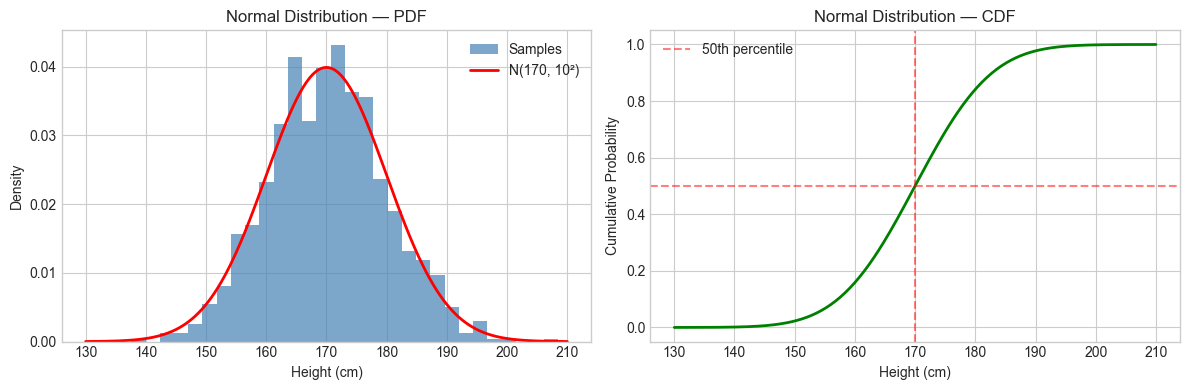

In [4]:
# Sampling from a normal distribution
samples = np.random.normal(loc=mu, scale=sigma, size=1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of samples
axes[0].hist(
    samples, bins=30, density=True, alpha=0.7, color="steelblue", label="Samples"
)
x = np.linspace(130, 210, 300)
axes[0].plot(x, dist.pdf(x), "r-", lw=2, label=f"N({mu}, {sigma}²)")
axes[0].set_title("Normal Distribution — PDF")
axes[0].set_xlabel("Height (cm)")
axes[0].set_ylabel("Density")
axes[0].legend()

# CDF
axes[1].plot(x, dist.cdf(x), "g-", lw=2)
axes[1].axhline(0.5, color="red", linestyle="--", alpha=0.5, label="50th percentile")
axes[1].axvline(mu, color="red", linestyle="--", alpha=0.5)
axes[1].set_title("Normal Distribution — CDF")
axes[1].set_xlabel("Height (cm)")
axes[1].set_ylabel("Cumulative Probability")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 2. Binomial Distribution

Models the number of **successes in n independent trials**, each with probability **p**.

Examples: coin flips, email click rates, defective items in a batch.

This is a **discrete** distribution — PMF instead of PDF.

In [ ]:
n_trials = 20  # send 20 emails
p_click = 0.3  # 30% click rate

binom_dist = stats.binom(n=n_trials, p=p_click)

# PMF: probability of exactly k successes
print("PMF — Probability of exactly k clicks:")
for k in [0, 5, 6, 7, 10, 20]:
    print(f"  P(X={k:2d}) = {binom_dist.pmf(k):.4f}")

# CDF: probability of at most k successes
print(f"\nP(X <= 6)  = {binom_dist.cdf(6):.4f}")
print(f"P(X >= 10) = {1 - binom_dist.cdf(9):.4f}")

# Mean and std
print(f"\nExpected clicks: {binom_dist.mean():.1f}")
print(f"Std deviation  : {binom_dist.std():.3f}")

In [ ]:
# Sampling + PMF plot
k_values = np.arange(0, n_trials + 1)
pmf_values = binom_dist.pmf(k_values)

samples_binom = np.random.binomial(n=n_trials, p=p_click, size=1000)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(k_values, pmf_values, alpha=0.6, color="steelblue", label="PMF (theoretical)")
# Empirical frequencies from samples
counts = np.bincount(samples_binom, minlength=n_trials + 1) / 1000
ax.plot(k_values, counts, "ro", markersize=5, label="Empirical (1000 samples)")
ax.set_title(f"Binomial Distribution — n={n_trials}, p={p_click}")
ax.set_xlabel("Number of Successes")
ax.set_ylabel("Probability")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Poisson Distribution

Models the **number of events in a fixed interval of time or space**, given events occur at a constant average rate **λ**.

Examples: number of customers per hour, server errors per day, taxi arrivals per minute.

In [ ]:
lam = 4.5  # average 4.5 orders per hour

poisson_dist = stats.poisson(mu=lam)

print("PMF — Probability of exactly k orders:")
for k in range(0, 12):
    bar = "█" * int(poisson_dist.pmf(k) * 100)
    print(f"  P(X={k:2d}) = {poisson_dist.pmf(k):.4f}  {bar}")

print(f"\nMean (λ): {poisson_dist.mean()}, Variance: {poisson_dist.var()}")
print("Note: for Poisson, mean == variance")

In [ ]:
# Compare Poisson distributions with different λ values
fig, ax = plt.subplots(figsize=(10, 5))
k_vals = np.arange(0, 20)

for lam_val, color in zip([1, 3, 6, 10], ["blue", "green", "orange", "red"]):
    pmf = stats.poisson(mu=lam_val).pmf(k_vals)
    ax.plot(k_vals, pmf, "o-", color=color, label=f"λ={lam_val}", alpha=0.8)

ax.set_title("Poisson Distribution for Different λ Values")
ax.set_xlabel("Number of Events (k)")
ax.set_ylabel("Probability")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Uniform Distribution

In [ ]:
# Continuous uniform — equally likely values in [a, b]
a, b = 0, 10
uniform_dist = stats.uniform(loc=a, scale=b - a)  # scale = b - a

print(f"PDF at x=5  : {uniform_dist.pdf(5):.4f}")  # 1/(b-a) = 0.1 everywhere
print(f"P(X <= 5)   : {uniform_dist.cdf(5):.4f}")  # 0.5
print(f"P(3 < X < 7): {uniform_dist.cdf(7) - uniform_dist.cdf(3):.4f}")  # 0.4

# Sampling
uniform_samples = np.random.uniform(low=a, high=b, size=1000)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(-1, 11, 300)
ax.hist(
    uniform_samples,
    bins=20,
    density=True,
    alpha=0.6,
    color="steelblue",
    label="Samples",
)
ax.plot(x, uniform_dist.pdf(x), "r-", lw=2, label="PDF")
ax.set_title(f"Uniform Distribution — [{a}, {b}]")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Central Limit Theorem (CLT)

**No matter what the original distribution is**, the distribution of the **sample mean** approaches a Normal distribution as sample size increases.

This is why the Normal distribution is so important in statistics and ML.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
sample_sizes = [1, 2, 5, 10, 30, 100]

population = np.random.exponential(scale=2, size=100_000)  # heavily skewed

for ax, n in zip(axes.flat, sample_sizes):
    # Draw 5000 samples of size n, compute each mean
    sample_means = [np.random.choice(population, size=n).mean() for _ in range(5000)]
    ax.hist(sample_means, bins=40, density=True, color="steelblue", alpha=0.7)
    ax.set_title(f"n = {n}  (mean={np.mean(sample_means):.2f})")
    ax.set_xlabel("Sample Mean")

fig.suptitle(
    "Central Limit Theorem — Sample Means of an Exponential Population", y=1.02
)
plt.tight_layout()
plt.show()
print("Population is exponential (skewed). Sample means converge to Normal as n grows.")

---
## Summary

| Distribution | Type | Key Params | Use Case |
|---|---|---|---|
| Normal | Continuous | μ, σ | Heights, errors, many natural phenomena |
| Binomial | Discrete | n, p | Successes in n trials |
| Poisson | Discrete | λ | Events per unit of time/space |
| Uniform | Continuous | a, b | Equal probability across a range |

**Key scipy.stats methods:**
- `.pdf(x)` — probability density at x (continuous)
- `.pmf(k)` — probability mass at k (discrete)
- `.cdf(x)` — P(X ≤ x)
- `.ppf(q)` — inverse CDF (x such that P(X ≤ x) = q)
- `.mean()`, `.std()`, `.var()` — distribution statistics
- `.rvs(size=n)` — random variates (samples)